# Lab 03 Cheatsheet
**Geometric Transformations: Linear, Affine, Rigid, Similarity & Projective** | CV Practical Lab Exam

Everything below uses only the syntax from `geometric.ipynb` (`imread`, `cvtColor`, `resize`, `getRotationMatrix2D`, `warpAffine`, `getPerspectiveTransform`, `warpPerspective`, `np.float32` matrices, `plt.subplot`) plus a handful of small extras that are flagged where they appear.

### Contents
| # | Section | # | Section |
|---|---|---|---|
| 0 | Setup | 8 | Task 6 - Similarity (scale + rotate + translate) |
| 1 | The transformation hierarchy (big picture) | 9 | Task 7 - General affine from 3 point pairs |
| 2 | Key concepts: matrices, canvas, `warpAffine` | 10 | Task 8 - Perspective rectification (bird's-eye) |
| 3 | Task 1 - Scale (centred) | 11 | Task 9 - Homography & panorama stitching |
| 4 | Task 2 - Rotation (no cropped corners) | 12 | Task 10 - Full hierarchy (scale -> rigid -> projective) |
| 5 | Task 3 - Shear | 13 | Function quick reference |
| 6 | Task 4 - Translation (3x3 homogeneous) | 14 | Common errors & exam checklist |
| 7 | Task 5 - Rigid (rotation + translation) | | |

**One-line recipe for every task:** `build the matrix (by hand) -> work out where the result lands (canvas / centre) -> warpAffine / warpPerspective -> show before vs after`

---
## 0. Setup
Run this cell first. The templates below are plain scripts (no helper functions): copy a template, change the lines marked `# EDIT`, run.

**Where each cell loads its image from:** `images/<name>`. Change the path to the exam file.

**Display pattern used everywhere** (same as `geometric.ipynb`):
```python
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))   # OpenCV is BGR -> convert for matplotlib
plt.title('Before')
plt.axis('off')
```

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 70

---
# 1. The transformation hierarchy (big picture)

Each level **adds freedom** and **loses an invariant**. Every transformation is a matrix multiplication on homogeneous coordinates `[x, y, 1]`.

| Level | Matrix | DOF | Preserves | Example (task) | OpenCV |
|---|---|---|---|---|---|
| **Linear** (2x2) | `[[a,b],[c,d]]` | 4 | origin, lines through origin | scale, rotation, shear (1-3) | `warpAffine` / `resize` |
| **Translation** | `[[1,0,tx],[0,1,ty]]` | 2 | shape, size, angles, orientation | slide map (4) | `warpAffine` |
| **Rigid** (Euclidean) | rotation + translation, `R^T R = I` | 3 | **distances**, angles, areas | align chip (5) | `warpAffine` |
| **Similarity** | scale x rotation + translation | 4 | **angles**, ratios of lengths | fix blueprint (6) | `warpAffine` |
| **Affine** | `[[a,b,c],[d,e,f]]` | 6 | **parallel lines** | glitched photo (7) | `warpAffine`, `getAffineTransform` |
| **Projective** (homography) | 3x3, `h33 = 1` | 8 | **straight lines** only | sidewalk, panorama, frame (8-10) | `warpPerspective`, `getPerspectiveTransform` |

**Points needed to determine each:** rigid/similarity -> 2 points, affine -> **3 points** (6 equations), projective -> **4 points** (8 equations).

**Containment:** rigid is inside similarity, which is inside affine, which is inside projective.

**Why 3x3?** A 2x2 matrix cannot encode translation. Adding a constant `1` coordinate turns translation into a matrix multiplication, so any chain of transformations collapses into one matrix. OpenCV's affine functions take just the top two rows (`M3[:2]`) of the 3x3.

---
# 2. Key concepts: matrices, canvas, `warpAffine`

**`cv2.warpAffine(src, M, (width, height))`**
- `M` is a **2x3** `np.float32` matrix `[[a, b, tx], [c, d, ty]]`: `x' = a*x + b*y + tx`, `y' = c*x + d*y + ty`.
- `M` maps **source -> destination** (OpenCV inverts it internally).
- `dsize` is **(width, height)**, the reverse of `img.shape[:2]` (= `(height, width)`).
- Anything landing outside `dsize` is **cut off**; empty areas get `borderValue` (black by default).
- `flags = cv2.INTER_LINEAR` (default) or `cv2.INTER_CUBIC` (smoother).

**`cv2.warpPerspective(src, H, (width, height))`**: same idea with a full **3x3** `H`.

**Rotation with OpenCV:** `M = cv2.getRotationMatrix2D(center, angle, scale)`
- Rotates about `center` (leaves `center` fixed) and scales by `scale`.
- **Positive angle = counter-clockwise.** (A hand-written `[[cos,-sin],[sin,cos]]` rotates **clockwise** on screen because y points down.)

**Rotate / scale about a point, then move it:** build `M` with `getRotationMatrix2D(c, angle, scale)` and add the shift to the last column:
```python
M[0, 2] += new_x - c[0]
M[1, 2] += new_y - c[1]
```
This is exactly **rotation + translation in one matrix** (rigid when `scale = 1`, similarity otherwise).

**Keeping the centre fixed after scaling:** `tx = cx - sx*cx`, `ty = cy - sy*cy`.

**Canvas size after rotating a `w x h` image by `theta`:** `W' = w*|cos| + h*|sin|`, `H' = w*|sin| + h*|cos|`.

**Combining 3x3 matrices** (extra syntax): `M_total = M_second @ M_first`. The matrix applied **first** is on the **right**.

**Coordinates:** a point is `(x, y) = (column, row)`; indexing is `img[row, col] = img[y, x]`.

In [2]:
# ---------- Sanity-check template: build, combine, undo ----------
M1 = np.float32([[1, 0, 100],
                 [0, 1, 50],
                 [0, 0, 1]])              # translate by (100, 50)
M2 = np.float32([[2, 0, 0],
                 [0, 2, 0],
                 [0, 0, 1]])              # scale x2
M_total = M1 @ M2                         # scale first, then translate
point = np.float32([10, 20, 1])
print('step by step :', M1 @ (M2 @ point))
print('single matrix:', M_total @ point)  # identical
print('undo         :', np.linalg.inv(M_total) @ (M_total @ point))   # back to (10, 20, 1)

step by step : [120.  90.   1.]
single matrix: [120.  90.   1.]
undo         : [10. 20.  1.]


---
# 3. Task 1 - Scale (centred)
**Scenario:** enlarge a tiny fingerprint 300 % on x and y and keep it centred on the screen.

| Step | What | Formula / call |
|---|---|---|
| 1 | 2x2 scaling matrix | `S = np.float32([[sx, 0], [0, sy]])` |
| 2 | Scaling is about the **origin** (top-left), so the print drifts away | - |
| 3 | Translation that keeps the centre fixed | `tx = cx - sx*cx`, `ty = cy - sy*cy` |
| 4 | Stack into a 2x3 matrix and warp | `cv2.warpAffine(img, M, (w, h))` |

**Pitfalls**
- Same-size canvas = the enlarged print is **cropped** (expected for a zoom).
- To show *everything*, use a canvas `(int(w*sx), int(h*sy))` and `tx = ty = 0`.
- `cv2.resize(img, None, fx, fy)` also scales, but the task asks for a manual matrix.

S =
 [[3. 0.]
 [0. 3.]]
M =
 [[   3.    0. -500.]
 [   0.    3. -500.]]


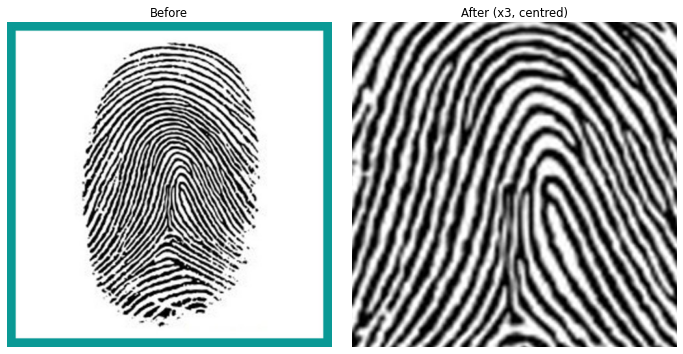

In [3]:
# ---------- TEMPLATE: manual scaling matrix, centred ----------
img = cv2.imread('images/fingerprint.jpg')                 # EDIT: image
height, width = img.shape[:2]

scale_x = 3                                                # EDIT: 300 %
scale_y = 3
S = np.float32([[scale_x, 0],
                [0, scale_y]])                             # 2x2 scaling matrix
print('S =\n', S)

cx = width / 2
cy = height / 2
tx = cx - scale_x * cx                                     # keeps the centre where it was
ty = cy - scale_y * cy
M = np.float32([[scale_x, 0, tx],
                [0, scale_y, ty]])                         # 2x3
print('M =\n', M)

scaled = cv2.warpAffine(img, M, (width, height), flags = cv2.INTER_CUBIC)     # same screen size
# bigger canvas instead of cropping:  M2 = np.float32([[scale_x,0,0],[0,scale_y,0]])
#                                     cv2.warpAffine(img, M2, (width*scale_x, height*scale_y))

plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Before')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB))
plt.title('After (x3, centred)')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 4. Task 2 - Rotation (no cropped corners)
**Scenario:** a satellite photo is rotated 45 degrees; spin it back to true north without losing any corner.

| Step | What | Formula / call |
|---|---|---|
| 1 | 2x2 rotation matrix from sin and cos | `R = [[cos,-sin],[sin,cos]]` (`np.cos(np.radians(a))`) |
| 2 | New canvas so corners are not chopped | `new_w = w*abs(cos) + h*abs(sin)`, `new_h = w*abs(sin) + h*abs(cos)` |
| 3 | Rotate about the image centre, then put that centre in the middle of the new canvas | `tx = new_w/2 - (cos*w/2 - sin*h/2)`, `ty = new_h/2 - (sin*w/2 + cos*h/2)` |
| 4 | Warp onto `(new_w, new_h)` | `cv2.warpAffine(img, M, (new_w, new_h))` |

**Pitfalls**
- `dsize` is `(new_w, new_h)` = **(width, height)**.
- The result has empty corner triangles: that is the price of keeping every pixel. Slice out the middle if you need a tight result: `img[y0:y0+h, x0:x0+w]`.
- Hand-written `R` rotates **clockwise**; `getRotationMatrix2D` positive angles rotate **counter-clockwise**. Pick whichever undoes your tilt.

R =
 [[ 0.70710677 -0.70710677]
 [ 0.70710677  0.70710677]]


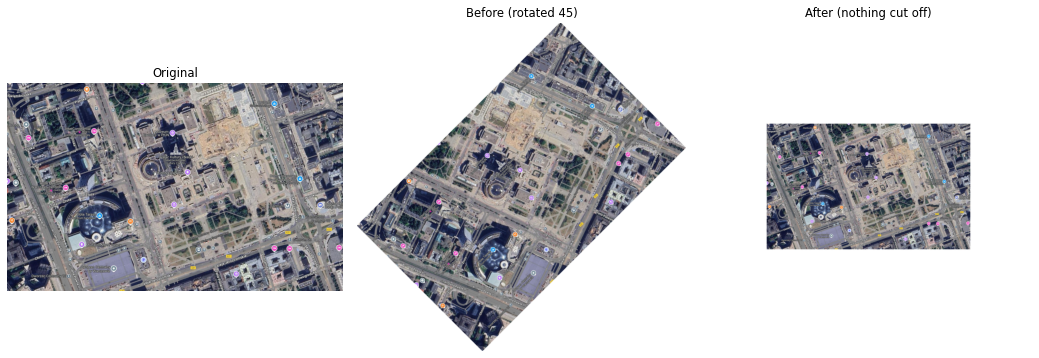

In [4]:
# ---------- TEMPLATE: rotation with an enlarged canvas ----------
img = cv2.imread('images/city.jpg')                        # EDIT: the rotated photo you are given
img = cv2.resize(img, None, fx = 0.5, fy = 0.5, interpolation = cv2.INTER_AREA)
height, width = img.shape[:2]

# --- (only to CREATE a "bad" photo; skip if you are GIVEN a rotated image) ---
center = (width // 2, height // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
cos = abs(M[0, 0])
sin = abs(M[0, 1])
tilt_w = int(height * sin + width * cos)
tilt_h = int(height * cos + width * sin)
M[0, 2] += tilt_w / 2 - center[0]
M[1, 2] += tilt_h / 2 - center[1]
tilted = cv2.warpAffine(img, M, (tilt_w, tilt_h), borderValue = (255, 255, 255))
# -----------------------------------------------------------------------------

angle = np.radians(45)                                     # EDIT: how far to turn it back
c = np.cos(angle)
s = np.sin(angle)
R = np.float32([[c, -s],
                [s,  c]])                                  # 2x2 rotation matrix
print('R =\n', R)

th, tw = tilted.shape[:2]
new_w = int(tw * abs(c) + th * abs(s))                     # canvas that holds every corner
new_h = int(tw * abs(s) + th * abs(c))

tx = new_w / 2 - (c * (tw / 2) - s * (th / 2))             # centre -> centre of the new canvas
ty = new_h / 2 - (s * (tw / 2) + c * (th / 2))
M = np.float32([[c, -s, tx],
                [s,  c, ty]])
fixed = cv2.warpAffine(tilted, M, (new_w, new_h), flags = cv2.INTER_CUBIC, borderValue = (255, 255, 255))

plt.figure(figsize = (15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(tilted, cv2.COLOR_BGR2RGB))
plt.title('Before (rotated 45)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(fixed, cv2.COLOR_BGR2RGB))
plt.title('After (nothing cut off)')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 5. Task 3 - Shear
**Scenario:** a barcode photographed on a moving train is slanted to the right; push the rows back to get a rectangle.

| Step | What | Formula / call |
|---|---|---|
| 1 | Horizontal shear matrix | `[[1, kx],[0, 1]]`: every pixel moves in x by `kx * y` |
| 2 | Slanted to the right (top pushed right) was made with `kx < 0` | slant = `[[1,-k],[0,1]]` |
| 3 | Fix = **inverse shear** | `[[1, +k],[0, 1]]` |
| 4 | Shear also drags the content sideways by `k * h` | add `tx = -k * h` so it lands back at x = 0 |
| 5 | Warp onto the **original** `(w, h)` canvas | `cv2.warpAffine(slanted, M, (w, h))` |

**Pitfalls**
- Wrong sign = the slant doubles instead of cancelling. Estimate `k` from the slant: `k = horizontal_offset / height` of a line that should be vertical.
- Vertical shear uses the **bottom-left** entry: `[[1,0],[ky,1]]`.
- Slanted image canvas width = `w + k*h`.

shear =
 [[1.   0.35]
 [0.   1.  ]]


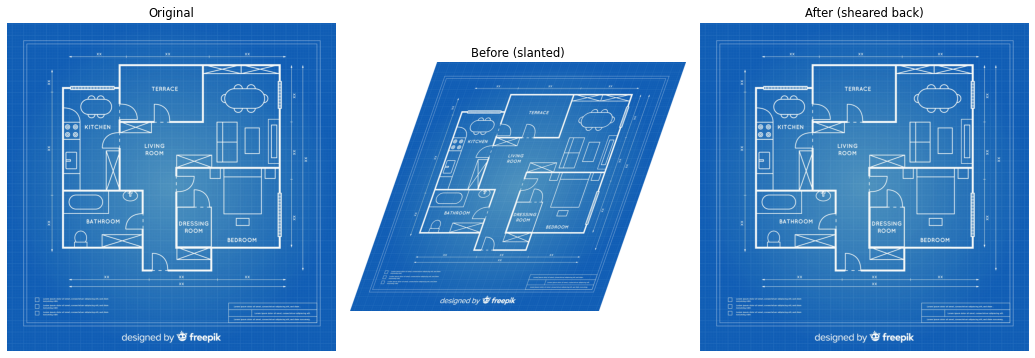

In [5]:
# ---------- TEMPLATE: horizontal shear and its inverse ----------
img = cv2.imread('images/blueprint.jpg')                   # EDIT: image
img = cv2.resize(img, None, fx = 0.5, fy = 0.5, interpolation = cv2.INTER_AREA)
height, width = img.shape[:2]

k = 0.35                                                   # EDIT: slant amount

# --- (only to CREATE the slanted scan; skip if you are GIVEN one) ---
M_slant = np.float32([[1, -k, k * height],
                      [0, 1, 0]])
slanted = cv2.warpAffine(img, M_slant, (int(width + k * height), height), borderValue = (255, 255, 255))
# --------------------------------------------------------------------

shear = np.float32([[1, k],
                    [0, 1]])                               # the corrective 2x2 shear matrix
print('shear =\n', shear)

M = np.float32([[1, k, -k * height],
                [0, 1, 0]])                                # shear + shift back by k*height
fixed = cv2.warpAffine(slanted, M, (width, height), flags = cv2.INTER_CUBIC, borderValue = (255, 255, 255))

plt.figure(figsize = (15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(slanted, cv2.COLOR_BGR2RGB))
plt.title('Before (slanted)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(fixed, cv2.COLOR_BGR2RGB))
plt.title('After (sheared back)')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 6. Task 4 - Translation (3x3 homogeneous)
**Scenario:** the map sits 150 px left and 80 px up of where it should be; slide it back into view.

| Step | What | Formula / call |
|---|---|---|
| 1 | 2x2 cannot translate, so go to **3x3** | `[[1,0,tx],[0,1,ty],[0,0,1]]` |
| 2 | Hidden **left/up** by (150, 80) -> move **right/down** | `tx = +150`, `ty = +80` |
| 3 | Compose with whatever already moved it | `M_total = M_fix @ M_now` |
| 4 | Warp with the top two rows | `cv2.warpAffine(img, M_total[:2], (w, h))` |

**Pitfalls**
- Positive `tx` -> **right**, positive `ty` -> **down** (y points down).
- Pixels pushed outside `(w, h)` are lost for good. Always warp from the **original** layer (`M_total`), not from an already-cropped screenshot.
- Translation never changes shape, size or orientation.
- `M[:2]` = first two rows of the 3x3 matrix (OpenCV wants 2x3).

M_total =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


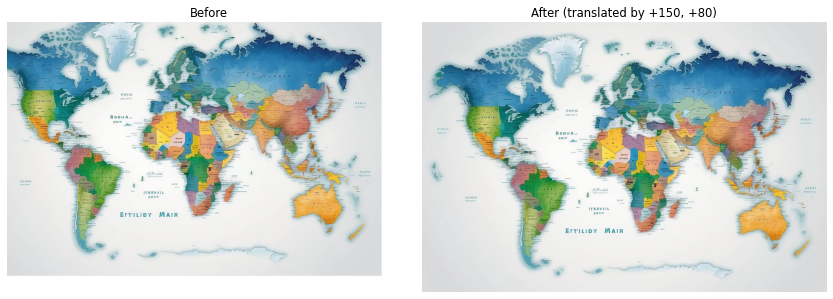

In [6]:
# ---------- TEMPLATE: translation ----------
img = cv2.imread('images/map.jpg')                         # EDIT: image
height, width = img.shape[:2]

M_now = np.float32([[1, 0, -150],
                    [0, 1, -80],
                    [0, 0, 1]])                            # EDIT: where the map currently sits (left 150, up 80)
M_fix = np.float32([[1, 0, 150],
                    [0, 1, 80],
                    [0, 0, 1]])                            # EDIT: the correction (right 150, down 80)
M_total = M_fix @ M_now                                    # identity here = back to the origin
print('M_total =\n', M_total)

misaligned = cv2.warpAffine(img, M_now[:2], (width, height), borderValue = (255, 255, 255))
aligned = cv2.warpAffine(img, M_total[:2], (width, height), borderValue = (255, 255, 255))

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(misaligned, cv2.COLOR_BGR2RGB))
plt.title('Before')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
plt.title('After (translated by +150, +80)')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 7. Task 5 - Rigid (rotation + translation)
**Scenario:** a chip lies rotated and off-centre on a conveyor belt; align it with the gripper using **one** matrix.

| Step | What | Formula / call |
|---|---|---|
| 1 | Rigid = rotation + translation, **scale = 1** | `R^T R = I`, `det R = +1` |
| 2 | Rotate about the chip's current centre `(cx, cy)` | `M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)` |
| 3 | Move that centre onto the gripper centre `(gx, gy)` | `M[0,2] += gx - cx`, `M[1,2] += gy - cy` |
| 4 | Apply the single matrix | `cv2.warpAffine(img, M, (W, H))` |
| 5 | Verify no scaling | `(M[0,0]**2 + M[0,1]**2) ** 0.5 == 1` |

**Pitfalls**
- `angle` is how far you must turn it **back** (positive = counter-clockwise on screen).
- Rotation about `(cx, cy)` keeps that point fixed, so the translation afterwards is just `g - c`.
- Any scale other than 1 makes it a **similarity**, not rigid.
- Real jobs apply the matrix to the **chip layer only**; here the belt is a flat colour, so warping the whole image is fine (`borderValue` = belt colour).

M =
 [[ 4.22618262e-01  9.06307787e-01  1.11148260e+02]
 [-9.06307787e-01  4.22618262e-01  5.06105552e+02]]
scale check (must be 1): 1.0


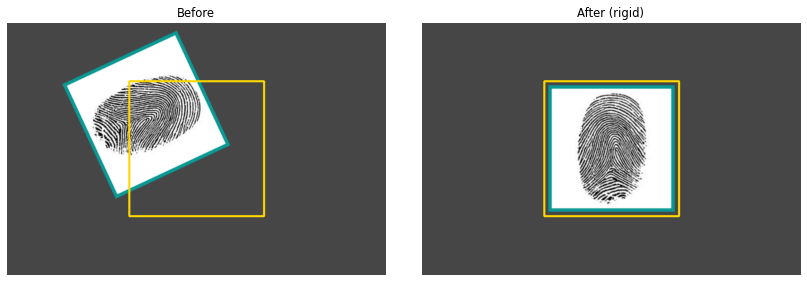

In [7]:
# ---------- TEMPLATE: rigid transformation ----------
chip = cv2.imread('images/fingerprint.jpg')                # EDIT: object image
chip = cv2.resize(chip, None, fx = 0.6, fy = 0.6)
chip_h, chip_w = chip.shape[:2]
belt_w = 900
belt_h = 600
belt_color = (70, 70, 70)

# --- (only to CREATE the "bad" scene; skip if you are GIVEN a belt photo) ---
M_place = cv2.getRotationMatrix2D((chip_w / 2, chip_h / 2), -65, 1.0)    # rotated 65 deg clockwise
M_place[0, 2] += 330 - chip_w / 2                                        # centre sits at (330, 220)
M_place[1, 2] += 220 - chip_h / 2
before = cv2.warpAffine(chip, M_place, (belt_w, belt_h), borderValue = belt_color)
# ---------------------------------------------------------------------------

chip_x, chip_y = 330, 220                                  # EDIT: measured chip centre
chip_angle = 65                                            # EDIT: angle to turn it BACK (counter-clockwise +)
gripper_x, gripper_y = 450, 300                            # EDIT: gripper centre

M = cv2.getRotationMatrix2D((chip_x, chip_y), chip_angle, 1.0)    # rotation, scale stays 1
M[0, 2] += gripper_x - chip_x                                     # + translation in the same matrix
M[1, 2] += gripper_y - chip_y
print('M =\n', M)
print('scale check (must be 1):', (M[0, 0] ** 2 + M[0, 1] ** 2) ** 0.5)

after = cv2.warpAffine(before, M, (belt_w, belt_h), borderValue = belt_color)

for im in (before, after):
    cv2.rectangle(im, (gripper_x - 160, gripper_y - 160), (gripper_x + 160, gripper_y + 160), (0, 215, 255), 4)

plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(before, cv2.COLOR_BGR2RGB))
plt.title('Before')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(after, cv2.COLOR_BGR2RGB))
plt.title('After (rigid)')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 8. Task 6 - Similarity (scale + rotate + translate)
**Scenario:** a blueprint is too small, rotated and in the wrong corner; fix all three in **one** matrix.

| Step | What | Formula / call |
|---|---|---|
| 1 | Similarity = uniform scale + rotation + translation | `[[s cos, -s sin, tx],[s sin, s cos, ty]]` |
| 2 | Choose `s` = target size / current size, and the angle that undoes the rotation | - |
| 3 | Scale + rotate about the blueprint's current centre `(cx, cy)` | `M = cv2.getRotationMatrix2D((cx, cy), angle, s)` |
| 4 | Move that centre to the target `(gx, gy)` | `M[0,2] += gx - cx`, `M[1,2] += gy - cy` |
| 5 | Warp | `cv2.warpAffine(img, M, (W, H))` |

**Pitfalls**
- Only **uniform** scale: `sx != sy` is a general affine map, not a similarity.
- Check: `(M[0,0]**2 + M[0,1]**2) ** 0.5` must equal `s`.
- This one `M` does everything because rotation/scale about `(cx, cy)` leaves `(cx, cy)` in place and the added shift then carries it to `(gx, gy)`.

M =
 [[ 1.67802254e+00  6.10750256e-01 -1.61166052e+03]
 [-6.10750256e-01  1.67802254e+00 -3.77945004e+02]]
scale check (must be 1.786): 1.7857142857142858


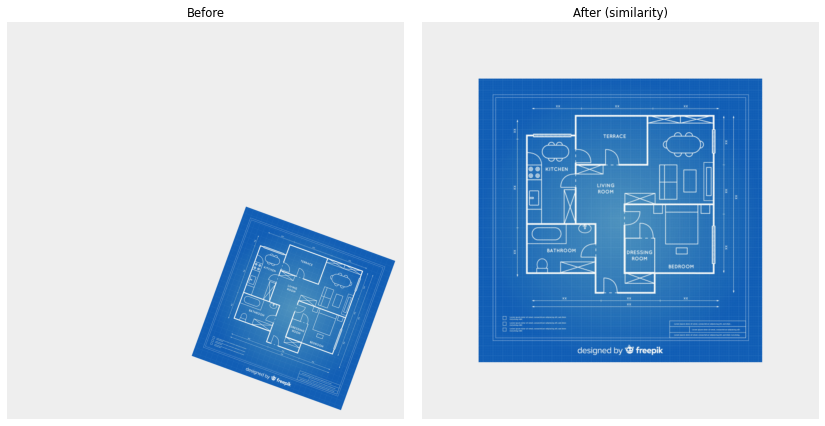

In [8]:
# ---------- TEMPLATE: similarity transformation in one matrix ----------
img = cv2.imread('images/blueprint.jpg')                   # EDIT: image
img = cv2.resize(img, None, fx = 0.28, fy = 0.28, interpolation = cv2.INTER_AREA)    # 560 x 560, "too small"
bh, bw = img.shape[:2]
canvas = 1400
gray = (238, 238, 238)

# --- (only to CREATE the "bad" import; skip if you are GIVEN one) ---
M_before = cv2.getRotationMatrix2D((bw / 2, bh / 2), -20, 1.0)     # rotated 20 deg clockwise
M_before[0, 2] += 1010 - bw / 2                                    # sits at (1010, 1010)
M_before[1, 2] += 1010 - bh / 2
before = cv2.warpAffine(img, M_before, (canvas, canvas), borderValue = gray)
# ---------------------------------------------------------------------

cur_x, cur_y = 1010, 1010                                  # EDIT: current centre of the blueprint
angle = 20                                                 # EDIT: angle that undoes its rotation
scale = 1000 / 560                                         # EDIT: target size / current size
goal_x, goal_y = 700, 700                                  # EDIT: where its centre should end up

M = cv2.getRotationMatrix2D((cur_x, cur_y), angle, scale)  # rotation + scale
M[0, 2] += goal_x - cur_x                                  # + translation
M[1, 2] += goal_y - cur_y
print('M =\n', M)
print('scale check (must be %.3f):' % scale, (M[0, 0] ** 2 + M[0, 1] ** 2) ** 0.5)

fixed = cv2.warpAffine(before, M, (canvas, canvas), flags = cv2.INTER_CUBIC, borderValue = gray)

plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(before, cv2.COLOR_BGR2RGB))
plt.title('Before')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(fixed, cv2.COLOR_BGR2RGB))
plt.title('After (similarity)')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 9. Task 7 - General affine from 3 point pairs
**Scenario:** a photo was squished, slanted, rotated and moved. You know where 3 landmarks are in the glitched photo and where they belong; solve for the 6 unknowns and fix it.

| Step | What | Formula / call |
|---|---|---|
| 1 | Affine map: `x' = ax+by+c`, `y' = dx+ey+f` -> **6 unknowns** | - |
| 2 | Each point pair gives 2 equations; 3 pairs -> 6 equations | rows `[x y 1 0 0 0]` and `[0 0 0 x y 1]` |
| 3 | Solve `A p = b` (extra syntax) | `np.linalg.solve(A, b)` |
| 4 | Put the 6 numbers into a 2x3 matrix | `[[a,b,c],[d,e,f]]` |
| 5 | Warp (output size = size of the **target** image) | `cv2.warpAffine(glitched, M, (w, h))` |

**Pitfalls**
- Pairs must go **glitched (start) -> correct (end)**, otherwise you build the glitch instead of the fix.
- The 3 points must **not be collinear**, or `solve` raises `LinAlgError`.
- Cross-check with `cv2.getAffineTransform(src, dst)` (needs `np.float32`, shape `(3,2)`).

M =
 [[   1.3918414    -0.42515847 -117.15911   ]
 [   0.3311122     0.98651063 -223.74982   ]]
OpenCV =
 [[   1.39184138   -0.42515846 -117.15910938]
 [   0.33111219    0.98651065 -223.74982393]]


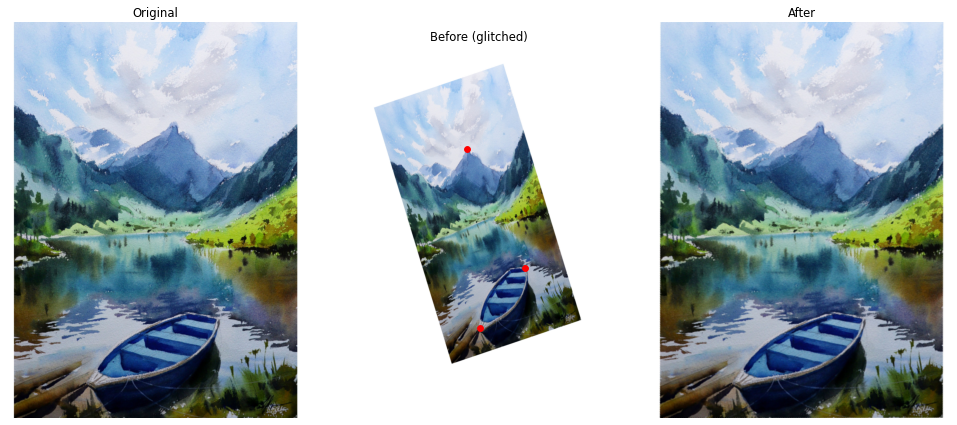

In [9]:
# ---------- TEMPLATE: solve the affine matrix by hand ----------
clean = cv2.imread('images/painting.jpg')                  # EDIT: reference image
clean = cv2.resize(clean, None, fx = 0.4, fy = 0.4, interpolation = cv2.INTER_AREA)
height, width = clean.shape[:2]

# --- (only to CREATE the "bad" photo; skip if you are GIVEN one) ---
M_glitch = np.float32([[0.65, 0.28, 140],
                       [-0.22, 0.92, 180]])
glitched = cv2.warpAffine(clean, M_glitch, (900, 1000), borderValue = (255, 255, 255))
# --------------------------------------------------------------------

# EDIT: landmark coordinates (x, y)
x1, y1 = 416, 296        # start: in the glitched photo
x2, y2 = 584, 639
x3, y3 = 452, 809
u1, v1 = 336, 206        # end: where they belong in the clean photo
u2, v2 = 424, 600
u3, v3 = 168, 724

A = np.array([[x1, y1, 1, 0, 0, 0],
              [0, 0, 0, x1, y1, 1],
              [x2, y2, 1, 0, 0, 0],
              [0, 0, 0, x2, y2, 1],
              [x3, y3, 1, 0, 0, 0],
              [0, 0, 0, x3, y3, 1]])
b = np.array([u1, v1, u2, v2, u3, v3])

a, b_, c, d, e, f = np.linalg.solve(A, b)
M = np.float32([[a, b_, c],
                [d, e, f]])
print('M =\n', M)
print('OpenCV =\n', cv2.getAffineTransform(np.float32([[x1, y1], [x2, y2], [x3, y3]]),
                                          np.float32([[u1, v1], [u2, v2], [u3, v3]])))

fixed = cv2.warpAffine(glitched, M, (width, height), flags = cv2.INTER_CUBIC, borderValue = (255, 255, 255))

plt.figure(figsize = (14,6))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(clean, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(glitched, cv2.COLOR_BGR2RGB))
plt.plot([x1, x2, x3], [y1, y2, y3], 'ro')
plt.title('Before (glitched)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(fixed, cv2.COLOR_BGR2RGB))
plt.title('After')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 10. Task 8 - Perspective rectification (bird's-eye)
**Scenario:** chalk art photographed from a low angle: the far edge looks smaller. Pick 4 corners that should form a perfect square and warp them to a true square.

| Step | What | Formula / call |
|---|---|---|
| 1 | Pick 4 source corners in the photo | consistent order, e.g. top, right, bottom, left |
| 2 | Define the 4 destination corners (a real square) | **same order** as the source |
| 3 | Solve the 8-unknown homography | `H = cv2.getPerspectiveTransform(src, dst)` |
| 4 | Warp onto an output canvas | `cv2.warpPerspective(img, H, (W, H_out))` |

**Pitfalls**
- `src` and `dst` must be `np.float32`, shape `(4, 2)`, in the **same corner order**; a swapped order gives a twisted/mirrored result.
- Choose the destination square **away from the output edge** and the canvas big enough, or the stretched surroundings fall outside.
- Read pixel coordinates from the `plt.imshow` axes (x along the bottom, y down the side) and note them down.
- A square rotated 45 degrees is a **diamond**: `[[cx, cy-r], [cx+r, cy], [cx, cy+r], [cx-r, cy]]`. An upright square is `[[x0,y0],[x1,y0],[x1,y1],[x0,y1]]`.

H =
 [[-4.44509628e+00 -2.92906747e+00  2.13952099e+03]
 [-3.39357332e-01 -1.33384172e+01  9.29225724e+03]
 [ 7.80855731e-04 -7.33785419e-03  1.00000000e+00]]


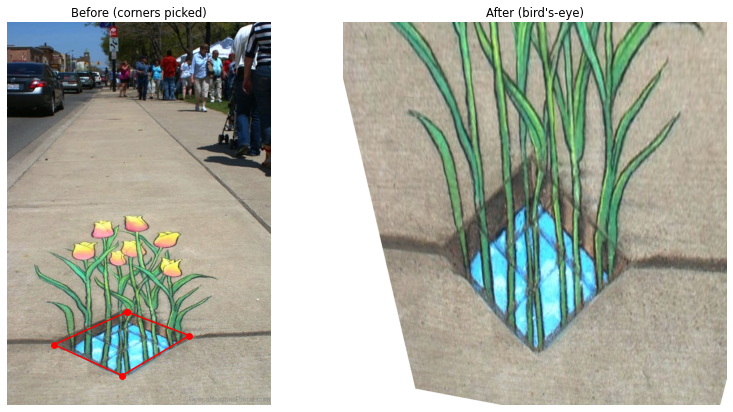

In [10]:
# ---------- TEMPLATE: perspective rectification ----------
img = cv2.imread('images/art.jpg')                         # EDIT: image

src_points = np.float32([[320, 775],                       # EDIT: 4 corners that should be a square
                         [487, 838],                       #       (top, right, bottom, left)
                         [307, 945],
                         [125, 862]])

dst_points = np.float32([[350, 260],                       # EDIT: the same 4 as a perfect square (same order)
                         [520, 430],                       #       here: a diamond, so the sidewalk stays vertical
                         [350, 600],
                         [180, 430]])

H = cv2.getPerspectiveTransform(src_points, dst_points)    # 3x3 homography
print('H =\n', H)
birdseye = cv2.warpPerspective(img, H, (700, 700), flags = cv2.INTER_CUBIC, borderValue = (255, 255, 255))

plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.plot([320, 487, 307, 125, 320], [775, 838, 945, 862, 775], 'r-o')     # shows the picked corners
plt.title('Before (corners picked)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(birdseye, cv2.COLOR_BGR2RGB))
plt.title("After (bird's-eye)")
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 11. Task 9 - Homography & panorama stitching
**Scenario:** two cameras photograph the same field and share a small overlap. Select 4 matching points, compute the homography and stitch camera 2 into camera 1's space.

| Step | What | Formula / call |
|---|---|---|
| 1 | 4 matching points: `pts2` (image to move) and `pts1` (image that stays) | same landmarks, **same order** |
| 2 | Homography **camera 2 -> camera 1** | `H = cv2.getPerspectiveTransform(pts2, pts1)` |
| 3 | Where do camera 2's corners land? (extra syntax) | `warped = H @ corners.T`, then divide by the last row |
| 4 | Canvas = far edge of the warped corners (and camera 1) | `pano_w = int(warped[0].max())` |
| 5 | Warp camera 2 onto the canvas | `cv2.warpPerspective(cam2, H, (pano_w, pano_h))` |
| 6 | Paste camera 1 on top (it is already in its own space) | `pano[0:h1, 0:w1] = cam1` |

**Pitfalls**
- Direction: points go **from the image you warp to the image that stays**. Swapping them stitches the wrong way.
- If a warped corner has a **negative** x or y, that part falls outside the canvas: shift everything with a translation first (`M_shift @ H`).
- Points should be **spread out** over the overlap, not clustered, and no 3 of them in a line.
- Edges of the panorama have empty wedges: crop them with slicing, `pano[y0:y1, x0:x1]`.
- Exposure differences leave a visible seam; match brightness or blend the overlap with `cv2.addWeighted`.

H =
 [[ 8.63202620e-01  2.65728142e-02  7.80096011e+02]
 [-3.56135235e-02  9.39464750e-01  3.01820666e+01]
 [-8.09136192e-05  9.08108025e-06  1.00000000e+00]]
warped corners (x row, y row):
 [[ 780.09601109 1679.26633434 1691.87528204  800.23200553]
 [  30.18206661   -2.016986   1044.13852692 1000.56686552]]


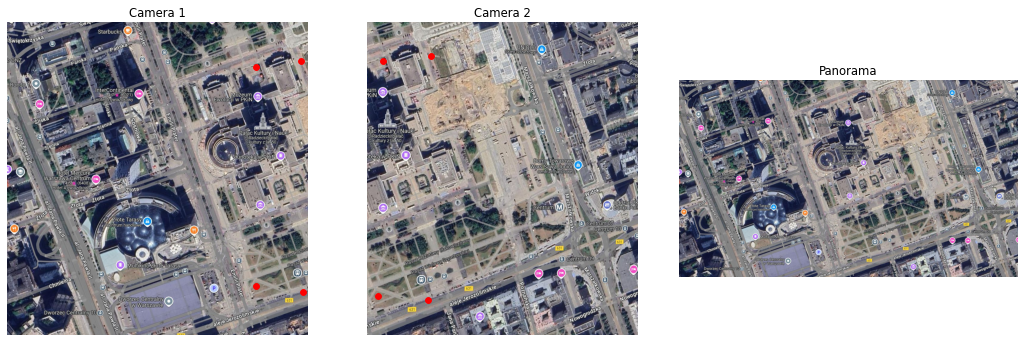

In [11]:
# ---------- TEMPLATE: homography stitching ----------
city = cv2.imread('images/city.jpg')                       # EDIT: (here both cameras are made from one photo)
height, width = city.shape[:2]

cam1 = city[:, :1000]                                      # EDIT: camera 1 image (the one that stays)

# --- (only to CREATE camera 2; skip if you are GIVEN two photos) ---
view = np.float32([[780, 30], [1680, 0], [1690, 1043], [800, 1000]])
cam2_shape = np.float32([[0, 0], [900, 0], [900, 1043], [0, 1043]])
H_cam2 = cv2.getPerspectiveTransform(view, cam2_shape)
cam2 = cv2.warpPerspective(city, H_cam2, (900, 1043), flags = cv2.INTER_CUBIC)
# --------------------------------------------------------------------

pts1 = np.float32([[830, 150], [980, 130], [985, 900], [830, 880]])      # EDIT: 4 points in camera 1
pts2 = np.float32([[51, 129], [210, 112], [200, 926], [35, 911]])        # EDIT: the SAME 4 points in camera 2

H = cv2.getPerspectiveTransform(pts2, pts1)                # camera 2 -> camera 1
print('H =\n', H)

# canvas size: where do the 4 corners of camera 2 land?
h2, w2 = cam2.shape[:2]
corners2 = np.float32([[0, 0, 1], [w2, 0, 1], [w2, h2, 1], [0, h2, 1]]).T
warped = H @ corners2
warped = warped[:2] / warped[2]
print('warped corners (x row, y row):\n', warped)
pano_w = int(warped[0].max())
pano_h = int(max(warped[1].max(), cam1.shape[0]))

pano = cv2.warpPerspective(cam2, H, (pano_w, pano_h), flags = cv2.INTER_CUBIC)
pano[0:cam1.shape[0], 0:cam1.shape[1]] = cam1              # camera 1 stays where it is
pano = pano[35:1010, 0:1670]                               # EDIT: crop the empty wedges

plt.figure(figsize = (15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(cam1, cv2.COLOR_BGR2RGB))
plt.plot(pts1[:, 0], pts1[:, 1], 'ro')
plt.title('Camera 1')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(cam2, cv2.COLOR_BGR2RGB))
plt.plot(pts2[:, 0], pts2[:, 1], 'ro')
plt.title('Camera 2')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
plt.title('Panorama')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 12. Task 10 - Full hierarchy (scale -> rigid -> projective)
**Scenario:** put a flat painting into an empty, heavily angled frame on a wall, travelling through the whole hierarchy.

| Step | Level | Call | Purpose |
|---|---|---|---|
| 1 | **Linear scale** | `cv2.resize(paint, None, fx, fy)` | shrink the painting to roughly frame size |
| 2 | **Rigid** | `getRotationMatrix2D((cx,cy), angle, 1.0)` + `M[0,2] += ...` | rotate a little and move it near the frame |
| 3 | **Corners after step 2** | `corners @ M_rigid.T` (extra syntax) | where the painting's 4 corners now are |
| 4 | **Projective** | `H = getPerspectiveTransform(moved_corners, frame_corners)` | pin them onto the 4 inner frame corners |
| 5 | **Layering** | wall -> painting -> frame (alpha) | painting sits *behind* the frame |

**Pitfalls**
- The projective step needs the painting's corners **after steps 1-2**, in the order `TL, TR, BR, BL`, matching the frame's `TL, TR, BR, BL`.
- Painting and frame openings have different shapes: crop the painting (slicing) to the opening's ratio, or accept distortion.
- To hide hairline gaps, nudge the destination corners ~1 % outward so the painting tucks under the frame.
- A PNG frame has 4 channels (B, G, R, **alpha**): `cv2.imread(path, cv2.IMREAD_UNCHANGED)`. Blend with `out = back * (1 - alpha) + front * alpha`, where `alpha = frame[:, :, 3:4] / 255`.
- Frame inner corners: read them from the picture (like Task 8).

H =
 [[ 1.87989253e+00 -2.64201752e-01  2.70364048e+02]
 [ 6.34762009e-01  1.33575906e+00 -5.54621630e+02]
 [ 7.19236562e-04 -1.01082276e-04  1.00000000e+00]]


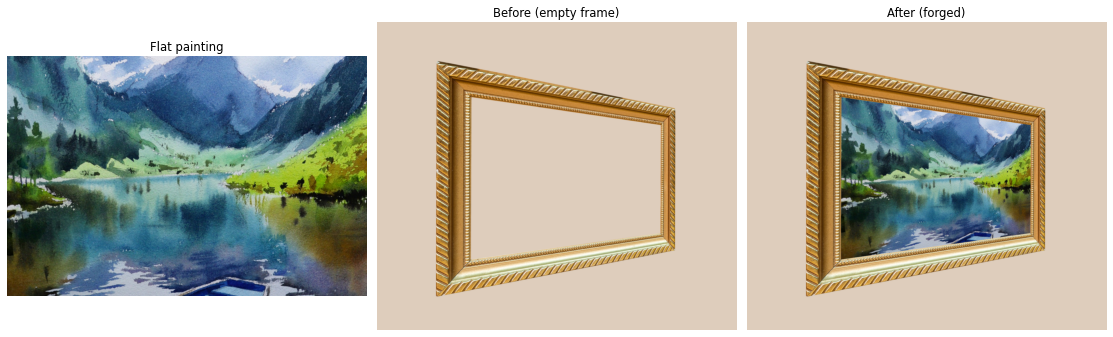

In [12]:
# ---------- TEMPLATE: scale -> rigid -> projective (frame forgery) ----------
# --- (only to CREATE the scene; skip if you are GIVEN a photo of the wall with the frame) ---
frame = cv2.imread('images/frame.png', cv2.IMREAD_UNCHANGED)       # 4 channels (B, G, R, alpha)
opening = frame[299:1120, 320:1584, 3]                             # alpha inside the empty opening
opening[opening < 128] = 0                                         # clean specks

scene_w = 1400
scene_h = 1200
wall = np.full((scene_h, scene_w, 3), (188, 205, 222), np.uint8)
flat_corners = np.float32([[173, 148], [1735, 148], [1735, 1273], [173, 1273]])
angled_corners = np.float32([[230, 150], [1160, 330], [1160, 890], [230, 1070]])
H_scene = cv2.getPerspectiveTransform(flat_corners, angled_corners)
frame_scene = cv2.warpPerspective(frame, H_scene, (scene_w, scene_h))
alpha = np.float32(frame_scene[:, :, 3:4]) / 255
empty_scene = np.uint8(wall * (1 - alpha) + frame_scene[:, :, :3] * alpha)
# ---------------------------------------------------------------------------------------------

paint = cv2.imread('images/painting.jpg')                          # EDIT: painting
paint = paint[600:1540, 45:1455]                                   # EDIT: crop to the opening's 3:2 shape

# 1) LINEAR SCALE
small = cv2.resize(paint, None, fx = 0.5, fy = 0.5, interpolation = cv2.INTER_AREA)       # EDIT: factor
sh, sw = small.shape[:2]

# 2) RIGID: rotate + move near the frame
M_rigid = cv2.getRotationMatrix2D((sw / 2, sh / 2), 8, 1.0)        # EDIT: angle
M_rigid[0, 2] += 520 - sw / 2                                      # EDIT: where the centre goes
M_rigid[1, 2] += 760 - sh / 2
moved = cv2.warpAffine(small, M_rigid, (scene_w, scene_h))

# where are the painting's 4 corners now?  (TL, TR, BR, BL)
corners = np.float32([[0, 0, 1], [sw, 0, 1], [sw, sh, 1], [0, sh, 1]])
moved_corners = np.float32(corners @ M_rigid.T)

# 3) PROJECTIVE: those 4 corners -> the 4 inner corners of the angled frame (TL, TR, BR, BL)
frame_inner = np.float32([[363, 291], [1105, 396], [1105, 823], [363, 928]])     # EDIT: read from the picture
H = cv2.getPerspectiveTransform(moved_corners, frame_inner)
print('H =\n', H)
forged = cv2.warpPerspective(moved, H, (scene_w, scene_h), flags = cv2.INTER_CUBIC)

# layering: wall -> painting -> frame
mask = forged.sum(axis = 2) > 0                                    # pixels the painting covers
base = wall.copy()
base[mask] = forged[mask]
final = np.uint8(base * (1 - alpha) + frame_scene[:, :, :3] * alpha)

plt.figure(figsize = (16,6))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(paint, cv2.COLOR_BGR2RGB))
plt.title('Flat painting')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(empty_scene, cv2.COLOR_BGR2RGB))
plt.title('Before (empty frame)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB))
plt.title('After (forged)')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 13. Function quick reference

| Function | Signature / notes |
|---|---|
| `cv2.imread(path)` / `cv2.imread(path, cv2.IMREAD_UNCHANGED)` | Load as BGR / keep the alpha channel of a PNG; returns `None` if the path is wrong |
| `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` | Needed before `plt.imshow` |
| `cv2.resize(img, None, fx=, fy=, interpolation=)` | Scale shortcut; `INTER_AREA` to shrink, `INTER_CUBIC/LINEAR` to enlarge |
| `cv2.getRotationMatrix2D(center, angle, scale)` | 2x3 rotation+scale about `center`. **Positive angle = counter-clockwise** |
| `cv2.warpAffine(src, M2x3, (w, h), flags, borderValue)` | Affine warp; `M` maps **src -> dst**; `dsize = (width, height)` |
| `cv2.getAffineTransform(src3, dst3)` | 3 point pairs (`np.float32`, 3x2) -> 2x3 affine matrix |
| `cv2.getPerspectiveTransform(src4, dst4)` | 4 point pairs (`np.float32`, 4x2) -> 3x3 homography |
| `cv2.warpPerspective(src, H3x3, (w, h), flags, borderValue)` | Projective warp with a full 3x3 |
| `cv2.INTER_NEAREST / LINEAR / CUBIC` | Resampling quality: blocky / default / smooth |
| `np.float32([[...]])` | How every matrix is written |
| `A @ B`, `A.T`, `np.linalg.inv(A)`, `np.linalg.solve(A, b)` | *Extras:* combine, transpose, undo, solve a linear system |
| `plt.plot([x...], [y...], 'ro')` | *Extra:* mark points on the image shown by `plt.imshow` |
| `cv2.line / cv2.circle / cv2.rectangle` | *Extra:* draw shapes (the X on the map, the gripper box) |

**Matrix shapes at a glance** (2x3 form for `warpAffine`; add a `[0, 0, 1]` row for 3x3)

| Transformation | Matrix |
|---|---|
| Scale | `[[sx,0,0],[0,sy,0]]` |
| Rotation (clockwise on screen) | `[[cos,-sin,0],[sin,cos,0]]` |
| Shear (horizontal) | `[[1,kx,0],[0,1,0]]` |
| Translation | `[[1,0,tx],[0,1,ty]]` |
| Rigid | `[[cos,-sin,tx],[sin,cos,ty]]` |
| Similarity | `[[s cos,-s sin,tx],[s sin,s cos,ty]]` |
| Affine | `[[a,b,c],[d,e,f]]` |
| Projective | `[[a,b,c],[d,e,f],[g,h,1]]` |

---
# 14. Common errors & exam checklist

| Symptom | Cause | Fix |
|---|---|---|
| Output is blank / only part of the image visible | `dsize` too small, or the content landed at negative coordinates | Enlarge `dsize` and/or add a translation so the result starts at (0, 0) |
| Image comes out squashed / wrong shape | `dsize` given as `(h, w)` | `dsize = (width, height)` |
| Rotation goes the wrong way | `getRotationMatrix2D` is counter-clockwise; hand-written `R` is clockwise | Flip the sign of the angle |
| Combined matrix does the steps in the wrong order | Matrix product is right-to-left | `M = last @ ... @ first` |
| Scaled image drifts out of view | Scaling is about the origin | `tx = cx - sx*cx`, `ty = cy - sy*cy` |
| Shear doubles the slant | Wrong sign | Use the inverse (`-k`) |
| `getPerspectiveTransform` error / garbage | Points not `np.float32`, not shape `(4,2)`, or different order | `np.float32([...])`, same corner order in `src` and `dst` |
| Rectified view is mirrored/twisted | Corner order mismatch | Order both sets the same way |
| `LinAlgError: Singular matrix` | 3 landmarks are collinear (or duplicated) | Pick well-spread, non-collinear points |
| Stitch leaves the second image cut off | Warped corners fall at negative coordinates, or points swapped | Shift with a translation; points go **camera 2 -> camera 1** |
| Dark edges around a warped object | Interpolation against the black border | Use `borderValue` of the background colour |
| Colours look wrong in `plt.imshow` | OpenCV is BGR | `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` before showing |
| Image is `None` / `AttributeError: 'NoneType' ... shape` | Wrong path | Check the path string |

### Exam checklist
1. Load images, check `img.shape[:2]` (`(height, width)`).
2. Write the matrix **by hand** as `np.float32`, print it, and state the **hierarchy level**.
3. Decide the output canvas (same size, enlarged, or custom) and keep the centre / origin in mind.
4. Need **one** combined matrix? Use `getRotationMatrix2D` + `M[0,2] += ...`, or multiply 3x3s with `@` (right-to-left).
5. `warpAffine` for 2x3, `warpPerspective` for 3x3; `dsize = (w, h)`.
6. Show **before vs after** side by side with titles.
7. Sanity checks: rigid scale = 1, similarity scale = `s`, shear x inverse = identity, homography corners land on the destination corners.